# Support Vector Machine (SVM) for Binary Classification

Building an SVM model to predict customer churn using 
the Churn Prediction dataset. Comparing Linear and RBF kernels.

Tools: Python | Pandas | Scikit-learn | Matplotlib

In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

## Step 1: Load and Preprocess Dataset
Loading and encoding the Churn dataset.
Features scaled using StandardScaler — critical for SVM
since it is a distance based algorithm.

In [3]:
df = pd.read_csv("../../Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv")

In [4]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
columns = df.select_dtypes(include="object").columns.tolist()
one_hot_columns = columns[1:]
print(one_hot_columns)

['International plan', 'Voice mail plan']


In [6]:
df = pd.get_dummies(df, columns = one_hot_columns, drop_first = True, dtype=int)

In [7]:
le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])

In [8]:
df.head()

,State,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,International plan_Yes,Voice mail plan_Yes
0,16,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,0,1
1,35,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,0,1
2,31,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,0,0
3,35,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,1,0
4,36,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1,0


In [9]:
df = df.rename(columns = {
    "International plan_Yes": "International Plan",
    "Voice mail plan_Yes" : "Voice Mail Plan"
})

## Step 2: Train Test Split
Splitting into 80% training and 20% testing.
Target: Churn (0 = No Churn, 1 = Churn)

In [10]:
x = df.drop(columns=['Churn'])
y= df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(2132, 19)
(534, 19)


In [11]:
df.nunique()

State                       51
Account length             205
Area code                    3
Number vmail messages       42
Total day minutes         1489
Total day calls            115
Total day charge          1489
Total eve minutes         1442
Total eve calls            120
Total eve charge          1301
Total night minutes       1444
Total night calls          118
Total night charge         885
Total intl minutes         158
Total intl calls            21
Total intl charge          158
Customer service calls      10
Churn                        2
International Plan           2
Voice Mail Plan              2
dtype: int64

In [18]:
columns_to_exclude = ['State', 'Area code', 'International Plan', 'Voice Mail Plan']
columns_to_scale = [col for col in x_train.columns if col not in columns_to_exclude]


scaler = StandardScaler()
x_train[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale] = scaler.transform(x_test[columns_to_scale])

x_train.head()


,State,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,International Plan,Voice Mail Plan
1855,49,0.707542,415,-0.59607,-0.392367,-0.012951,-0.392100,0.043716,-0.486238,0.043090,0.613995,-0.220652,0.614186,0.480926,0.616777,0.487104,0.348115,0,0
2244,25,-0.583812,415,-0.59607,-1.716003,-1.325348,-1.715955,0.282660,-2.077045,0.283062,-0.008990,2.417279,-0.008372,0.225113,0.616777,0.229914,-0.423383,0,0
2525,30,-1.672601,408,-0.59607,-0.781672,0.744202,-0.781405,-0.816868,-0.883940,-0.816238,0.273116,0.917279,0.274609,0.042390,-0.999159,0.040406,2.662612,0,0
961,26,-1.925808,415,-0.59607,-0.852118,-0.113904,-0.852287,0.039831,0.458304,0.040805,-0.114780,-0.013756,-0.112858,0.882918,0.212793,0.879656,0.348115,0,0
1618,26,-1.039584,415,-0.59607,-0.653757,1.652784,-0.653818,0.171930,-0.386813,0.171075,2.482952,0.606934,2.481860,1.613812,-0.999159,1.610616,-0.423383,0,0


## Step 3: Train SVM with Linear and RBF Kernels
Linear Kernel → straight hyperplane, no transformation
RBF Kernel    → transforms data to higher dimensions
                for non-linearly separable data

class_weight='balanced' used to handle class imbalance.

In [19]:
model_linear = SVC(kernel="linear", random_state=42, class_weight="balanced")
model_linear.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [26]:
model_rbf = SVC(kernel="rbf", random_state=42, C=1000, class_weight="balanced")
model_rbf.fit(x_train, y_train)

,C,1000
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


## Step 4: Compare Linear vs RBF Performance
Evaluating both kernels using Accuracy, Precision, Recall, F1 and AUC.
Linear kernel outperforms RBF → churn data is roughly linearly separable!

In [27]:


# linear predictions
y_pred_linear = model_linear.predict(x_test)

# rbf predictions
y_pred_rbf = model_rbf.predict(x_test)

print("Linear Kernel:")
print(f'Accuracy:  {accuracy_score(y_test, y_pred_linear):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_linear):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_linear):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_linear):.4f}')

print("\nRBF Kernel:")
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rbf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rbf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rbf):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_rbf):.4f}')

Linear Kernel:
Accuracy:  0.7509
Precision: 0.3393
Recall:    0.7215
F1 Score:  0.4615

RBF Kernel:
Accuracy:  0.7378
Precision: 0.3237
Recall:    0.7089
F1 Score:  0.4444


In [30]:
print(f'Linear AUC: {roc_auc_score(y_test, y_pred_linear):.4f}')
print(f'RBF AUC:    {roc_auc_score(y_test, y_pred_rbf):.4f}')

Linear AUC: 0.7388
RBF AUC:    0.7259


## Step 5: Visualize Decision Boundary
Visualizing the Linear kernel decision boundary using 
the top 2 features: Total day charge and Customer service calls.
Mesh grid used to color every region based on model predictions.

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# use only 2 features for visualization
X_vis = x_train[['Total day charge', 'Customer service calls']].values
y_vis = y_train.values

# train SVM on 2 features
model_vis = SVC(kernel='linear', class_weight='balanced', random_state=42)
model_vis.fit(X_vis, y_vis)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


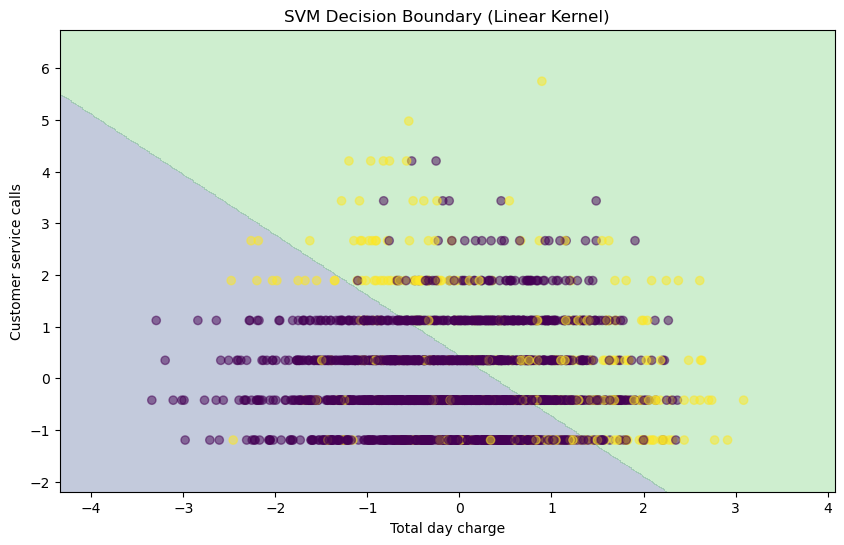

In [33]:
# create mesh grid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# predict on mesh grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, alpha=0.5)
plt.xlabel('Total day charge')
plt.ylabel('Customer service calls')
plt.title('SVM Decision Boundary (Linear Kernel)')
plt.show()

## Step 6: ROC Curve Comparison
Plotting ROC curves for both kernels.
Both curves well above random guessing baseline.
Linear kernel has slightly higher AUC (0.7388 vs 0.7259).

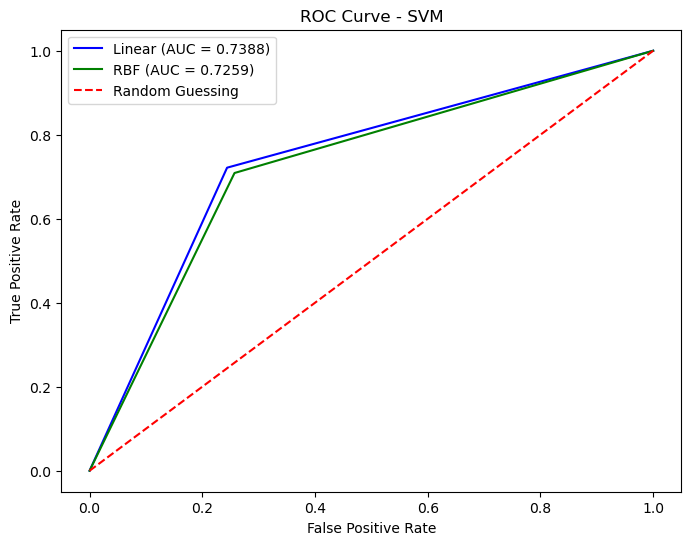

In [35]:
from sklearn.metrics import roc_curve

fpr_linear, tpr_linear, _ = roc_curve(y_test, y_pred_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_pred_rbf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='blue', label=f'Linear (AUC = 0.7388)')
plt.plot(fpr_rbf, tpr_rbf, color='green', label=f'RBF (AUC = 0.7259)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()
plt.show()